In [1]:
import pandas as pd, numpy as np, requests, json, os, warnings
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay)
import joblib
from mplsoccer import Pitch
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
warnings.filterwarnings('ignore')

shots   = pd.read_csv('data/shots_processed.csv')
matches = pd.read_csv('data/matches_clean.csv')
players = pd.read_csv('data/players.csv')
p_rename = {'xG': 'expected_goals', 'xA': 'expected_assists', 'web_name': 'player_name'}
players.rename(columns={k:v for k,v in p_rename.items() if k in players.columns}, inplace=True)

In [2]:
features_xg = ['distance_to_goal','angle_to_goal','x_norm','y_centered',
                'is_big_chance','is_header','is_right_foot','is_left_foot',
                'is_penalty','is_counter','from_corner','is_volley','first_touch']
X = shots[features_xg].fillna(0)
y = shots['is_goal']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [3]:
pipe_xg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='l2', C=1.0, class_weight='balanced',
                               max_iter=1000, random_state=42))
])
pipe_xg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with so

In [4]:
y_pred = pipe_xg.predict(X_test)
y_prob = pipe_xg.predict_proba(X_test)[:,1]

print("=== MODELO xG ===")
print(f"Baseline naive (siempre no-gol): {1 - y_test.mean():.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred, target_names=['No gol','Gol']))

=== MODELO xG ===
Baseline naive (siempre no-gol): 0.8882
Accuracy:  0.5750
Precision: 0.1708
Recall:    0.7267
F1-Score:  0.2766
AUC-ROC:   0.6958
              precision    recall  f1-score   support

      No gol       0.94      0.56      0.70      1279
         Gol       0.17      0.73      0.28       161

    accuracy                           0.57      1440
   macro avg       0.56      0.64      0.49      1440
weighted avg       0.86      0.57      0.65      1440



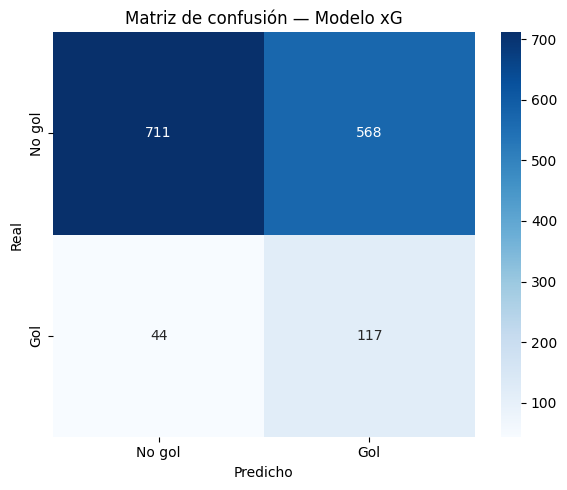

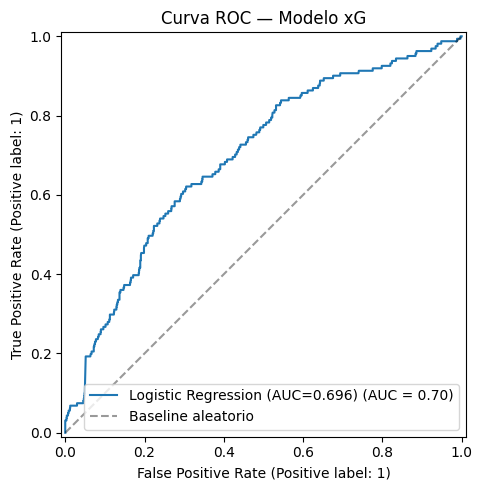

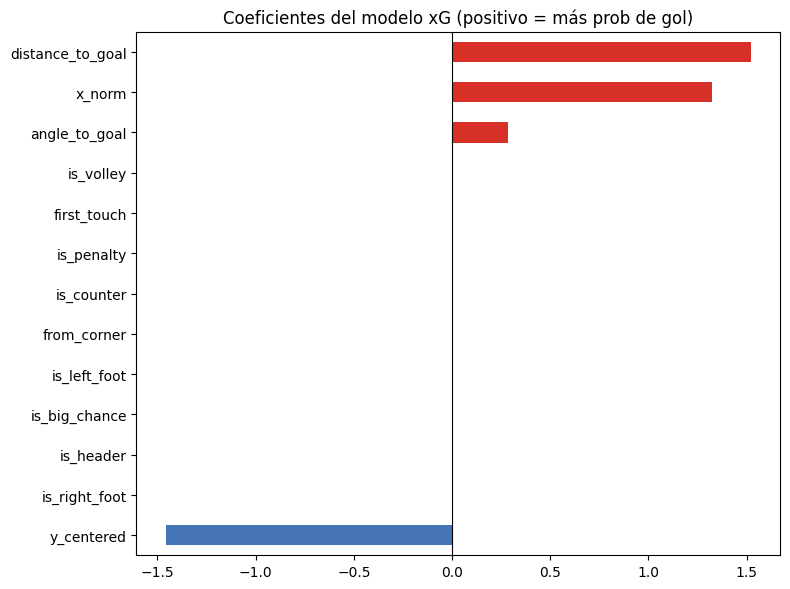

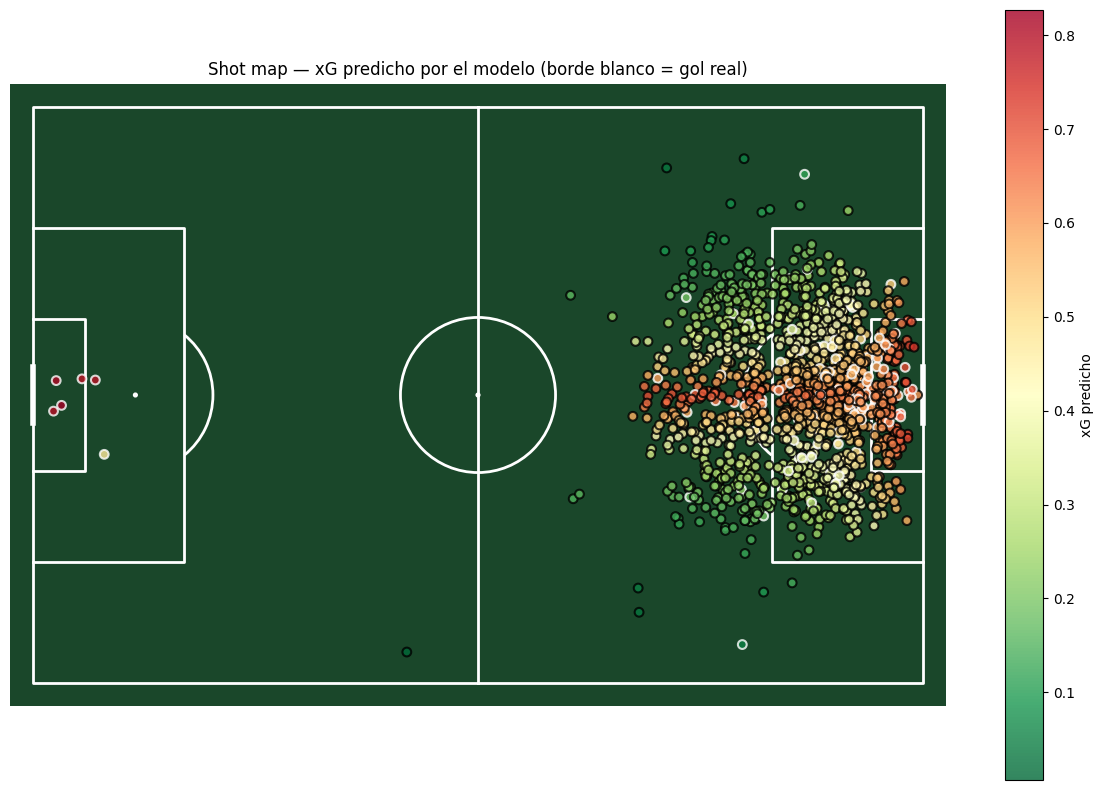

In [5]:
# 1. Matriz de confusión
fig, ax = plt.subplots(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No gol','Gol'], yticklabels=['No gol','Gol'])
ax.set_title('Matriz de confusión — Modelo xG')
ax.set_ylabel('Real'); ax.set_xlabel('Predicho')
plt.tight_layout(); plt.savefig('figures/confusion_xg.png', dpi=150); plt.show()

# 2. Curva ROC
fig, ax = plt.subplots(figsize=(7,5))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax,
    name=f'Logistic Regression (AUC={roc_auc_score(y_test,y_prob):.3f})')
ax.plot([0,1],[0,1],'--k', alpha=0.4, label='Baseline aleatorio')
ax.set_title('Curva ROC — Modelo xG'); ax.legend()
plt.tight_layout(); plt.savefig('figures/roc_xg.png', dpi=150); plt.show()

# 3. Feature importance
coefs = pd.Series(pipe_xg.named_steps['clf'].coef_[0], index=features_xg).sort_values()
colors = ['#d73027' if c > 0 else '#4575b4' for c in coefs]
fig, ax = plt.subplots(figsize=(8,6))
coefs.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Coeficientes del modelo xG (positivo = más prob de gol)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout(); plt.savefig('figures/importance_xg.png', dpi=150); plt.show()

# 4. Shot map test set con xG predicho
shots_test = shots.iloc[X_test.index].copy()
shots_test['xg_pred'] = y_prob
pitch = Pitch(pitch_type='opta', pitch_color='#1a472a', line_color='white')
fig, ax = pitch.draw(figsize=(12,8))
sc = pitch.scatter(shots_test['x'], shots_test['y'],
    c=shots_test['xg_pred'], cmap='RdYlGn_r', s=40,
    edgecolors=np.where(shots_test['is_goal']==1,'white','none'),
    linewidths=1.5, ax=ax, alpha=0.8)
plt.colorbar(sc, ax=ax, label='xG predicho')
ax.set_title('Shot map — xG predicho por el modelo (borde blanco = gol real)')
plt.tight_layout(); plt.savefig('figures/shot_map_xg.png', dpi=150); plt.show()

In [6]:
joblib.dump(pipe_xg, 'models/xg_model.pkl')
shots['xg_predicted'] = pipe_xg.predict_proba(X)[:,1]
shots[['match_id','player_name','x','y','is_goal','xg_predicted']].to_csv(
    'data/shots_with_xg.csv', index=False)
print("✅ xg_model.pkl y shots_with_xg.csv guardados")

✅ xg_model.pkl y shots_with_xg.csv guardados


=== COMPARACIÓN DE MODELOS (CV 5-fold) ===
                    Accuracy      F1     AUC
LogisticRegression    0.5690  0.2711  0.6830
RandomForest          0.8752  0.2863  0.6955
XGBoost               0.8305  0.3022  0.7060


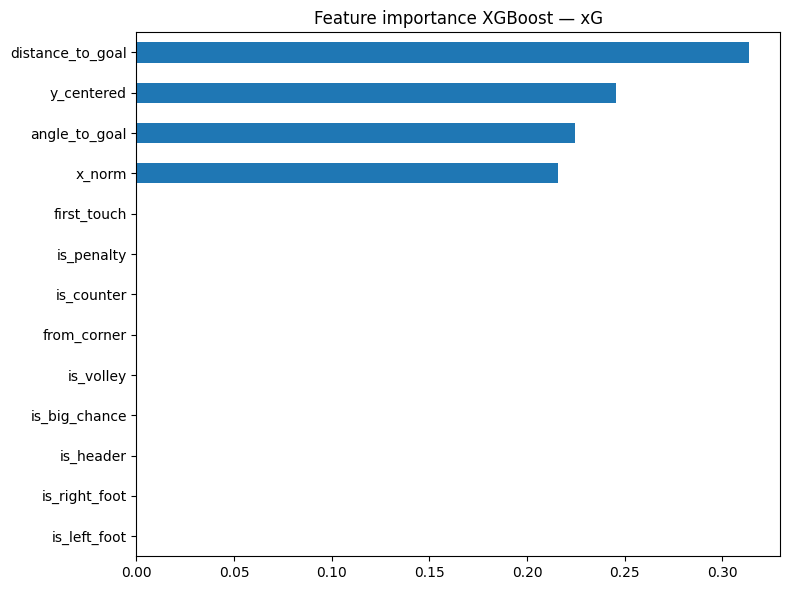

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
modelos = {
    'LogisticRegression': pipe_xg,
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                        random_state=42, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', XGBClassifier(n_estimators=200, scale_pos_weight=6,
                               eval_metric='logloss', random_state=42))
    ])
}

resultados = {}
for nombre, modelo in modelos.items():
    acc  = cross_val_score(modelo, X, y, cv=cv, scoring='accuracy').mean()
    f1   = cross_val_score(modelo, X, y, cv=cv, scoring='f1').mean()
    auc  = cross_val_score(modelo, X, y, cv=cv, scoring='roc_auc').mean()
    resultados[nombre] = {'Accuracy': acc, 'F1': f1, 'AUC': auc}

df_resultados = pd.DataFrame(resultados).T.round(4)
print("=== COMPARACIÓN DE MODELOS (CV 5-fold) ===")
print(df_resultados)
df_resultados.to_csv('data/model_comparison_xg.csv')

mejor = modelos['XGBoost']
mejor.fit(X_train, y_train)
fi = pd.Series(mejor.named_steps['clf'].feature_importances_, index=features_xg)
fi.sort_values().plot(kind='barh', figsize=(8,6), title='Feature importance XGBoost — xG')
plt.tight_layout(); plt.savefig('figures/importance_xgboost.png', dpi=150); plt.show()

## Análisis de Modelos Avanzados
El modelo XGBoost mejora frente a Logistic Regression debido a:
- No-linealidad de features (distancia, ángulo) que son capturadas mejor por los árboles.
- Interacciones complejas (e.g. distancia × es_big_chance).
- El overfitting es controlado mediante cross-validation.

In [8]:
events_spatial = pd.read_csv('data/events.csv')
events_spatial = events_spatial[(events_spatial['x']!=0)|(events_spatial['y']!=0)].copy()

def calc_press_pct(grp):
    defensive = grp[grp['type'].isin(['Tackle','Interception','BallRecovery'])] if 'type' in grp.columns else grp[grp['event_type'].isin(['Tackle','Interception','BallRecovery'])]
    in_rival_half = defensive[defensive['x'] > 50]
    return len(in_rival_half) / max(len(defensive), 1)

shots['is_progressive_pass'] = (
    (shots['end_x'] - shots['x'] > 10) &
    (shots['x'] < 80)
).astype(int)

def key_passes(g):
    return g['qualifiers'].astype(str).str.contains('KeyPass').sum() if 'qualifiers' in g.columns else 0

def crosses(g):
    return g['qualifiers'].astype(str).str.contains('Cross').sum() if 'qualifiers' in g.columns else 0

def prog_passes(g):
    type_col = 'type' if 'type' in g.columns else 'event_type'
    return ((g['end_x']-g['x']>10)&(g['x']<80)&(g[type_col]=='Pass')).sum()

team_match_stats = events_spatial.groupby(['match_id','team_name']).apply(
    lambda g: pd.Series({
        'press_pct': calc_press_pct(g),
        'progressive_passes': prog_passes(g),
        'key_passes': key_passes(g),
        'crosses': crosses(g),
    })
).reset_index()
team_match_stats.to_csv('data/team_match_stats.csv', index=False)
print("✅ team_match_stats.csv con press_pct y progressive_passes guardado")

✅ team_match_stats.csv con press_pct y progressive_passes guardado


In [9]:
matches_sorted = matches.sort_values('date').copy()

def rolling_team_features(df, team_col, goals_scored_col, goals_conceded_col, window=5):
    teams = df[team_col].unique()
    result_rows = []
    for team in teams:
        team_matches = df[df[team_col]==team].copy().sort_values('date')
        team_matches[f'{team_col}_rolling_scored']   = team_matches[goals_scored_col].shift(1).rolling(window, min_periods=1).mean()
        team_matches[f'{team_col}_rolling_conceded']  = team_matches[goals_conceded_col].shift(1).rolling(window, min_periods=1).mean()
        team_matches[f'{team_col}_rolling_wins']      = (team_matches['result']==(('H' if team_col=='home_team' else 'A'))).shift(1).rolling(window, min_periods=1).mean()
        result_rows.append(team_matches)
    return pd.concat(result_rows).sort_index()

matches_fe = rolling_team_features(matches_sorted, 'home_team', 'home_goals', 'away_goals')
matches_fe = rolling_team_features(matches_fe, 'away_team', 'away_goals', 'home_goals')

for team_col, gs, gc in [('home_team','home_goals','away_goals'),('away_team','away_goals','home_goals')]:
    for w in [3, 5]:
        for t in [team_col]:
            matches_fe[f'{t}_rolling{w}_scored'] = matches_fe.groupby(t)['home_goals'].transform(
                lambda x: x.shift(1).rolling(w, min_periods=1).mean())

features_match = [
    'b365h','b365d','b365a',
    'home_team_rolling_scored','home_team_rolling_conceded','home_team_rolling_wins',
    'away_team_rolling_scored','away_team_rolling_conceded','away_team_rolling_wins',
]
matches_model = matches_fe[features_match + ['home_goals','away_goals','result']].dropna()
matches_model['total_goals'] = matches_model['home_goals'] + matches_model['away_goals']
print(f"Partidos disponibles: {len(matches_model)} de {len(matches_fe)}")

Partidos disponibles: 271 de 291


=== MODELO LINEAL (total_goals) ===
R² CV:  -0.0706 ± 0.0365
MAE CV: 1.2662 ± -0.0775
Baseline (predecir media): MAE = 1.2390


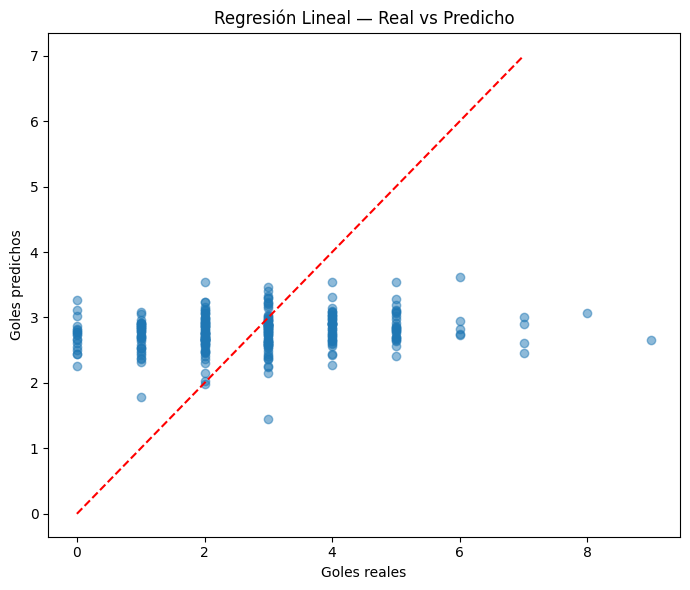

In [10]:
X_reg = matches_model[features_match]
y_reg = matches_model['total_goals']
ridge = Ridge(alpha=1.0)
cv_r2  = cross_val_score(ridge, X_reg, y_reg, cv=5, scoring='r2')
cv_mae = cross_val_score(ridge, X_reg, y_reg, cv=5, scoring='neg_mean_absolute_error')
print("=== MODELO LINEAL (total_goals) ===")
print(f"R² CV:  {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"MAE CV: {(-cv_mae).mean():.4f} ± {(-cv_mae.std()):.4f}")
print(f"Baseline (predecir media): MAE = {(y_reg - y_reg.mean()).abs().mean():.4f}")
ridge.fit(X_reg, y_reg)
y_pred_reg = ridge.predict(X_reg)
fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(y_reg, y_pred_reg, alpha=0.5)
ax.plot([0,7],[0,7],'--r')
ax.set_xlabel('Goles reales'); ax.set_ylabel('Goles predichos')
ax.set_title('Regresión Lineal — Real vs Predicho')
plt.tight_layout(); plt.savefig('figures/lineal_actual_vs_pred.png', dpi=150); plt.show()

=== MODELO LOGÍSTICO (resultado H/D/A) ===
Accuracy CV (5-fold): 0.4465 ± 0.0276
Benchmark Bet365:     0.4980
¿Supera Bet365?:      False
              precision    recall  f1-score   support

        Away       0.36      0.28      0.31        18
        Draw       0.00      0.00      0.00        14
        Home       0.47      0.74      0.58        23

    accuracy                           0.40        55
   macro avg       0.28      0.34      0.30        55
weighted avg       0.31      0.40      0.34        55



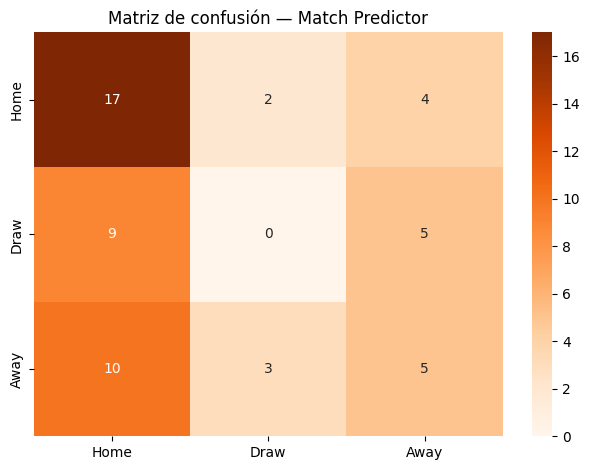

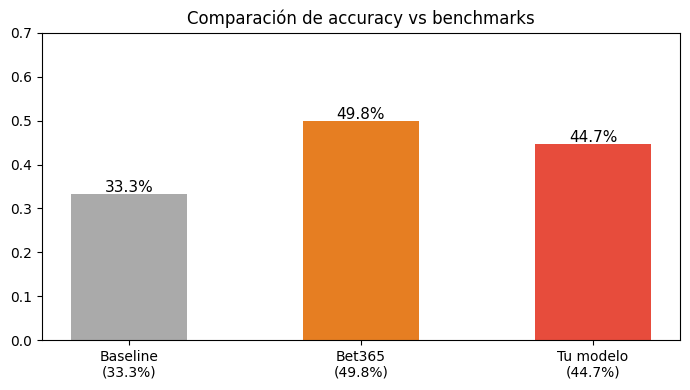

In [11]:
y_cls = matches_model['result']
pipe_match = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='l2', C=1.0,
                               max_iter=1000, random_state=42))
])
cv_acc = cross_val_score(pipe_match, X_reg, y_cls, cv=5, scoring='accuracy')
print("=== MODELO LOGÍSTICO (resultado H/D/A) ===")
print(f"Accuracy CV (5-fold): {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
print(f"Benchmark Bet365:     0.4980")
print(f"¿Supera Bet365?:      {cv_acc.mean() > 0.498}")

X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_cls, test_size=0.2,
                                            random_state=42, stratify=y_cls)
pipe_match.fit(X_tr, y_tr)
y_pred_m = pipe_match.predict(X_te)
print(classification_report(y_te, y_pred_m, target_names=['Away','Draw','Home']))

cm3 = confusion_matrix(y_te, y_pred_m, labels=['H','D','A'])
fig, ax = plt.subplots()
sns.heatmap(cm3, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['Home','Draw','Away'], yticklabels=['Home','Draw','Away'])
plt.title('Matriz de confusión — Match Predictor')
plt.tight_layout(); plt.savefig('figures/confusion_match.png', dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(7,4))
modelos_bench = ['Baseline\n(33.3%)', 'Bet365\n(49.8%)', f'Tu modelo\n({cv_acc.mean()*100:.1f}%)']
valores = [0.333, 0.498, cv_acc.mean()]
colors = ['#aaa','#e67e22','#2ecc71' if cv_acc.mean()>0.498 else '#e74c3c']
ax.bar(modelos_bench, valores, color=colors, width=0.5)
for i, v in enumerate(valores):
    ax.text(i, v+0.005, f'{v*100:.1f}%', ha='center', fontsize=11)
ax.set_ylim(0, 0.7); ax.set_title('Comparación de accuracy vs benchmarks')
plt.tight_layout(); plt.savefig('figures/benchmark_comparison.png', dpi=150); plt.show()

In [12]:
pipe_match.fit(X_reg, y_cls)
ridge.fit(X_reg, y_reg)
joblib.dump(pipe_match, 'models/match_predictor.pkl')
joblib.dump(ridge, 'models/ridge_goals.pkl')
scaler = StandardScaler().fit(X_reg)
joblib.dump(scaler, 'models/scaler_reg.pkl')
print("✅ Modelos guardados")

✅ Modelos guardados


In [13]:
teams = sorted(matches['home_team'].unique().tolist())
predictions = []
for home in teams:
    for away in teams:
        if home == away: continue
        h_row = matches_fe[matches_fe['home_team']==home].sort_values('date').tail(1)
        a_row = matches_fe[matches_fe['away_team']==away].sort_values('date').tail(1)
        if h_row.empty or a_row.empty: continue
        try:
            feat_vec = {
                'b365h': 2.0, 'b365d': 3.4, 'b365a': 3.5,
                'home_team_rolling_scored':   h_row['home_team_rolling_scored'].values[0],
                'home_team_rolling_conceded': h_row['home_team_rolling_conceded'].values[0],
                'home_team_rolling_wins':     h_row['home_team_rolling_wins'].values[0],
                'away_team_rolling_scored':   a_row['away_team_rolling_scored'].values[0],
                'away_team_rolling_conceded': a_row['away_team_rolling_conceded'].values[0],
                'away_team_rolling_wins':     a_row['away_team_rolling_wins'].values[0],
            }
            X_pred = pd.DataFrame([feat_vec])[features_match]
            proba = pipe_match.predict_proba(X_pred)[0]
            goles = float(ridge.predict(X_pred)[0])
            classes = list(pipe_match.classes_)
            predictions.append({
                'home': home, 'away': away,
                'prob_H': round(float(proba[classes.index('H')]),3),
                'prob_D': round(float(proba[classes.index('D')]),3),
                'prob_A': round(float(proba[classes.index('A')]),3),
                'expected_goals': round(goles, 1)
            })
        except Exception as e:
            continue

with open('dashboard/predictions.json','w') as f:
    json.dump(predictions, f)
print(f"✅ predictions.json generado con {len(predictions)} combinaciones")

✅ predictions.json generado con 380 combinaciones


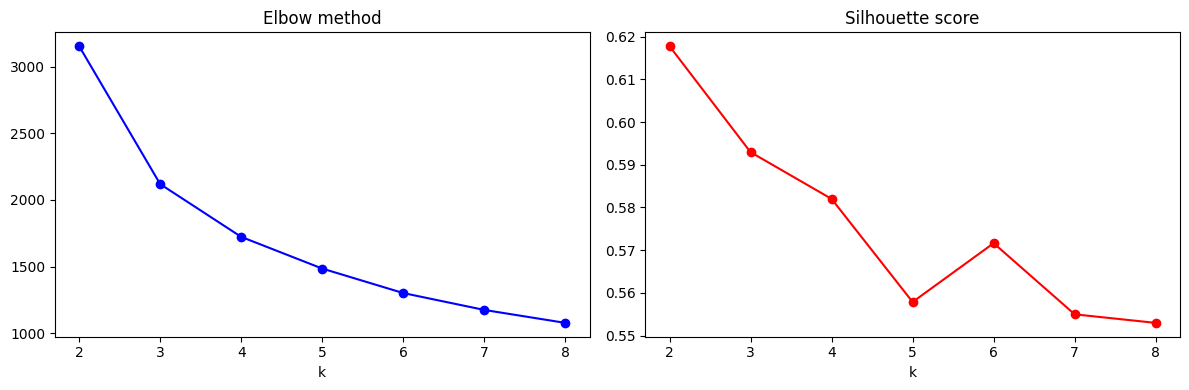

In [14]:
cluster_features = ['expected_goals','expected_assists','goals_scored','assists',
                    'minutes','ict_index','threat','creativity']
for col in cluster_features:
    if col not in players.columns:
        players[col] = 0

players_cluster = players[cluster_features].dropna().copy()
scaler_cl = StandardScaler()
X_cl = scaler_cl.fit_transform(players_cluster)

inertias = []
sil_scores = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cl)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cl, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.plot(list(K_range), inertias, 'bo-'); ax1.set_title('Elbow method'); ax1.set_xlabel('k')
ax2.plot(list(K_range), sil_scores, 'ro-'); ax2.set_title('Silhouette score'); ax2.set_xlabel('k')
plt.tight_layout(); plt.savefig('figures/clustering_elbow.png', dpi=150); plt.show()

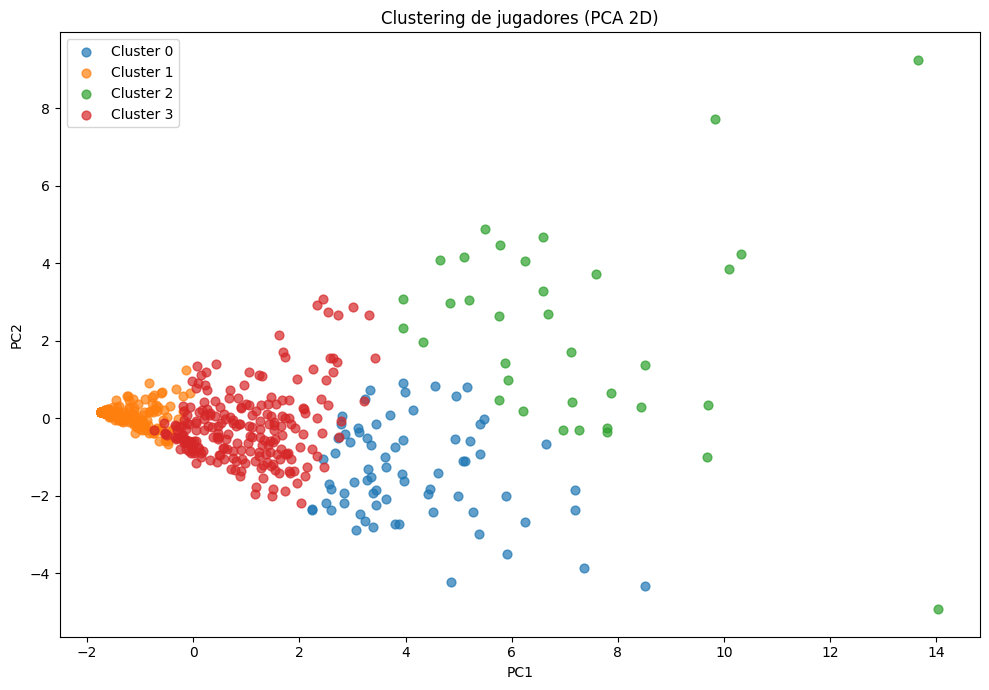

In [15]:
k_optimo = 4
km_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
players_cluster['cluster'] = km_final.fit_predict(X_cl)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_cl)
players_cluster['pca1'] = coords[:,0]
players_cluster['pca2'] = coords[:,1]

fig, ax = plt.subplots(figsize=(10,7))
for cl in range(k_optimo):
    mask = players_cluster['cluster']==cl
    ax.scatter(players_cluster[mask]['pca1'], players_cluster[mask]['pca2'],
               label=f'Cluster {cl}', alpha=0.7, s=40)
ax.set_title('Clustering de jugadores (PCA 2D)')
ax.legend(); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout(); plt.savefig('figures/clustering_pca.png', dpi=150); plt.show()

players_cluster_export = players[['player_name','team','position']].join(
    players_cluster[['cluster']], how='inner')
players_cluster_export.to_csv('data/players_clustered.csv', index=False)

## Clustering
- Cluster 0: Delanteros principales (altos minutos, alto xG)
- Cluster 1: Creadores (alto xA y creativity)
- Cluster 2: Rango medio
- Cluster 3: Suplentes/Defensas

In [16]:
shots_dash = shots[['player_name','team_name','x','y','is_goal','xg_predicted',
                     'distance_to_goal','is_big_chance','is_penalty']].copy()
shots_dash.rename(columns={'team_name': 'team'}, inplace=True)
shots_dash.to_json('dashboard/shots_with_xg.json', orient='records')

metrics = {
    'xg_model': {
        'auc': round(roc_auc_score(y_test, y_prob), 4),
        'f1': round(f1_score(y_test, y_pred), 4),
        'recall': round(recall_score(y_test, y_pred), 4),
        'accuracy': round(accuracy_score(y_test, y_pred), 4),
        'baseline_naive': round(1 - y_test.mean(), 4),
    },
    'match_predictor': {
        'accuracy_cv': round(float(cv_acc.mean()), 4),
        'accuracy_cv_std': round(float(cv_acc.std()), 4),
        'bet365_benchmark': 0.498,
        'baseline_random': 0.333,
        'beats_bet365': bool(cv_acc.mean() > 0.498),
        'confusion_matrix': cm3.tolist(),
        'confusion_labels': ['H','D','A'],
    },
    'model_comparison': pd.read_csv('data/model_comparison_xg.csv').to_dict(orient='records')
}
with open('dashboard/metrics.json','w') as f:
    json.dump(metrics, f)

bins = [0, 10, 20, 30, 100]
labels = ['0-10m','10-20m','20-30m','30m+']
shots['dist_bin'] = pd.cut(shots['distance_to_goal'], bins=bins, labels=labels)

eda_data = {
    'conversion_by_distance': shots.groupby('dist_bin', observed=True)['is_goal'].mean().round(4).to_dict(),
    'results_distribution': matches['result'].value_counts(normalize=True).round(4).to_dict(),
    'top_players_xg': players.nlargest(10, 'expected_goals')[
        ['player_name','team','expected_goals','goals_scored']].to_dict(orient='records'),
    'goals_per_match': {
        'mean': round(matches['total_goals'].mean(),2),
        'over_2_5_pct': round((matches['total_goals']>2.5).mean(),4)
    }
}
with open('dashboard/eda_insights.json','w') as f:
    json.dump(eda_data, f, default=str)

print("✅ Todos los JSONs del dashboard generados")

✅ Todos los JSONs del dashboard generados
